<a href="https://colab.research.google.com/github/sumitkharayat/Machine-learning-work/blob/main/Credit%20risk%20assesment%20of%20people.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Credit Risk Assessment

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
!ls "/content/drive/MyDrive/Applied ML lab"

'Exp-5,6,7,8 Data and Question-20260301'  'EXPERIMENT 2,3,4'
'EXPERIMENT 1'				  'Experiment 9-10'


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Applied ML lab/Exp-5,6,7,8 Data and Question-20260301/credit_risk_assessment_500_samples.csv")

print(df.head())
print(df.shape)

   Applicant_ID  Age  Annual_Income  Employment_Years  Credit_Score  \
0             1   59         153267                28           818   
1             2   49         232745                 0           436   
2             3   35         974945                19           797   
3             4   63         307164                29           776   
4             5   28         685626                 6           893   

   Loan_Amount  Loan_Term_Months  Existing_Loans_Count  Debt_to_Income_Ratio  \
0       196649                12                     2                  0.68   
1       175354                60                     0                  0.23   
2       662297                48                     3                  0.54   
3       831725                48                     0                  0.56   
4       498625                60                     3                  0.66   

   Late_Payments_Last_2Yrs Credit_Risk  
0                        0        High  
1         

In [ ]:
def load_data(path):
    df = pd.read_csv(path)
    return df


In [ ]:
loaded_df = load_data(data_path)
display(loaded_df.head())

,Applicant_ID,Age,Annual_Income,Employment_Years,Credit_Score,Loan_Amount,Loan_Term_Months,Existing_Loans_Count,Debt_to_Income_Ratio,Late_Payments_Last_2Yrs,Credit_Risk
0,1,59,153267,28,818,196649,12,2,0.68,0,High
1,2,49,232745,0,436,175354,60,0,0.23,5,High
2,3,35,974945,19,797,662297,48,3,0.54,0,Medium
3,4,63,307164,29,776,831725,48,0,0.56,4,High
4,5,28,685626,6,893,498625,60,3,0.66,8,High


Preprocessing

In [ ]:
def preprocess_data(df):
    # Handle missing values
    df = df.dropna()

    # Encode categorical columns
    le = LabelEncoder()
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = le.fit_transform(df[col])

    # Separate features and target
    X = df.drop('Credit_Risk', axis=1)
    y = df['Credit_Risk']

    return X, y

Feature scaling

In [ ]:
def scale_features(X_train, X_test):
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    return X_train, X_test


Spliting data


In [ ]:
def split_data(X, y):
    return train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
def get_models():
    return {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Random Forest": RandomForestClassifier(),
        "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
    }


In [ ]:
def train_and_evaluate(models, X_train, X_test, y_train, y_test):
    results = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        results[name] = acc

        print(f"\n{name}")
        print("Accuracy:", acc)
        print("Classification Report:\n", classification_report(y_test, y_pred))

    return results

In [ ]:
def get_best_model(models, results, X_test, y_test):
    best_name = max(results, key=results.get)
    best_model = models[best_name]

    print("\nBest Model:", best_name)

    y_pred = best_model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    return best_name, best_model, cm



In [ ]:
def plot_confusion_matrix(cm, model_name):
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title("Confusion Matrix - " + model_name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()



Logistic Regression
Accuracy: 0.84
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.93      0.89        58
           1       0.75      0.60      0.67         5
           2       0.82      0.73      0.77        37

    accuracy                           0.84       100
   macro avg       0.81      0.75      0.78       100
weighted avg       0.84      0.84      0.84       100


Random Forest
Accuracy: 0.97
Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99        58
           1       1.00      0.60      0.75         5
           2       0.95      0.97      0.96        37

    accuracy                           0.97       100
   macro avg       0.98      0.86      0.90       100
weighted avg       0.97      0.97      0.97       100


XGBoost
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.0

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:07:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


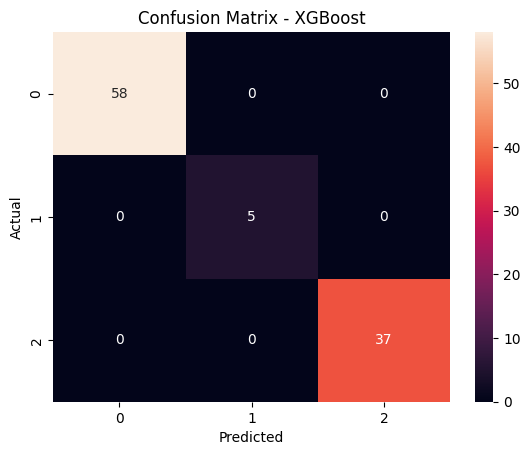

In [ ]:
def main():
    df = load_data("/content/drive/MyDrive/Applied ML lab/Exp-5,6,7,8 Data and Question-20260301/credit_risk_assessment_500_samples.csv") # Change filename if needed

    X, y = preprocess_data(df)

    X_train, X_test, y_train, y_test = split_data(X, y)

    X_train, X_test = scale_features(X_train, X_test)

    models = get_models()

    results = train_and_evaluate(models, X_train, X_test, y_train, y_test)

    best_name, best_model, cm = get_best_model(models, results, X_test, y_test)

    plot_confusion_matrix(cm, best_name)


if __name__ == "__main__":
    main()